In [1]:
!pip install pandas
import pandas as pd

In [29]:
g_icd = pd.read_csv("/Users/matiaslee/LOCAL_FILES_SAFE/Dr Facelli Project 2025/AS_DS/ICD-10 group incidence and prevalence.csv")
g_lab = pd.read_csv("/Users/matiaslee/LOCAL_FILES_SAFE/Dr Facelli Project 2025/AS_DS/LAB group incidence and prevalence.csv")
g_both = pd.read_csv("/Users/matiaslee/LOCAL_FILES_SAFE/Dr Facelli Project 2025/AS_DS/ICD + LAB group incidence and prevalence.csv")

g_icd

,Time Window Start,Time Window End,Incidence Proportion,Prevalence,Incidence Rate (cases/person-day)
0,2018-02-01,2018-02-28,0.006379,0.292259,0.000229
1,2018-03-01,2018-03-31,0.007246,0.295201,0.000236
2,2018-04-01,2018-04-30,0.006811,0.297918,0.000229
3,2018-05-01,2018-05-31,0.007566,0.301037,0.000246
4,2018-06-01,2018-06-30,0.006661,0.303660,0.000224
5,2018-07-01,2018-07-31,0.007234,0.306671,0.000235
6,2018-08-01,2018-08-31,0.007245,0.309493,0.000235
7,2018-09-01,2018-09-30,0.007091,0.312073,0.000238
8,2018-10-01,2018-10-31,0.007847,0.315175,0.000255
9,2018-11-01,2018-11-30,0.007369,0.318132,0.000247


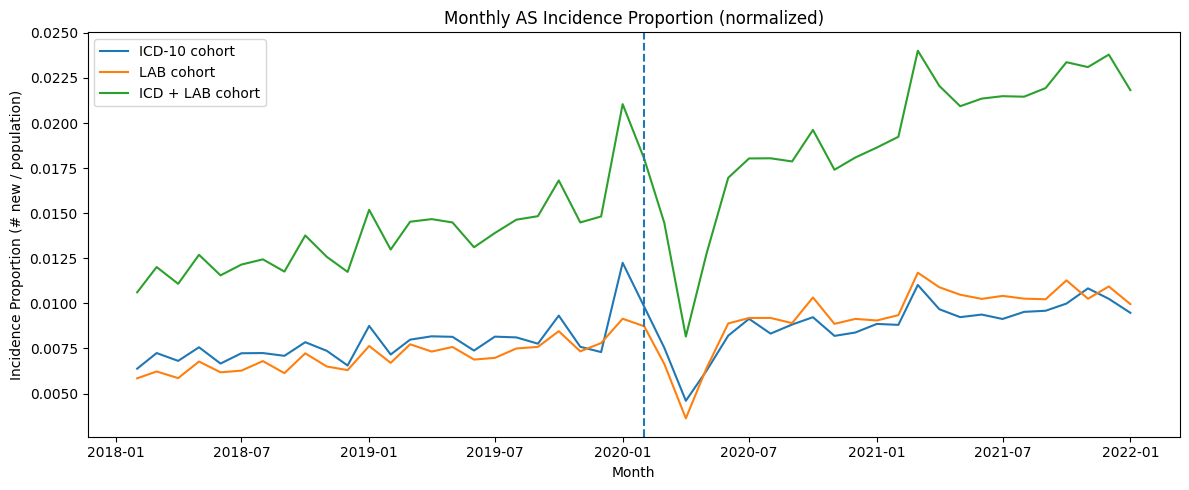

In [16]:
import matplotlib.pyplot as plt

def prep(df):
    df = df.copy()
    df["Time Window Start"] = pd.to_datetime(df["Time Window Start"])
    # Drop exact-duplicate months (or aggregate if needed)
    df = df.drop_duplicates(subset=["Time Window Start"])
    # If you ever expect multiple rows per month, use this instead:
    # df = (
    #     df.groupby("Time Window Start", as_index=False)["Incidence Proportion"]
    #       .mean()
    # )
    df = df.sort_values("Time Window Start")
    return df

g_icd = prep(g_icd)
g_lab = prep(g_lab)
g_both = prep(g_both)

# Plot incidence proportion
plt.figure(figsize=(12,5))
plt.plot(g_icd["Time Window Start"], g_icd["Incidence Proportion"], label="ICD-10 cohort")
plt.plot(g_lab["Time Window Start"], g_lab["Incidence Proportion"], label="LAB cohort")
plt.plot(g_both["Time Window Start"], g_both["Incidence Proportion"], label="ICD + LAB cohort")

# Mark Feb 2020 boundary
plt.axvline(pd.to_datetime("2020-02-01"), linestyle="--")

plt.title("Monthly AS Incidence Proportion (normalized)")
plt.xlabel("Month")
plt.ylabel("Incidence Proportion (# new / population)")
plt.legend()
plt.tight_layout()
plt.show()


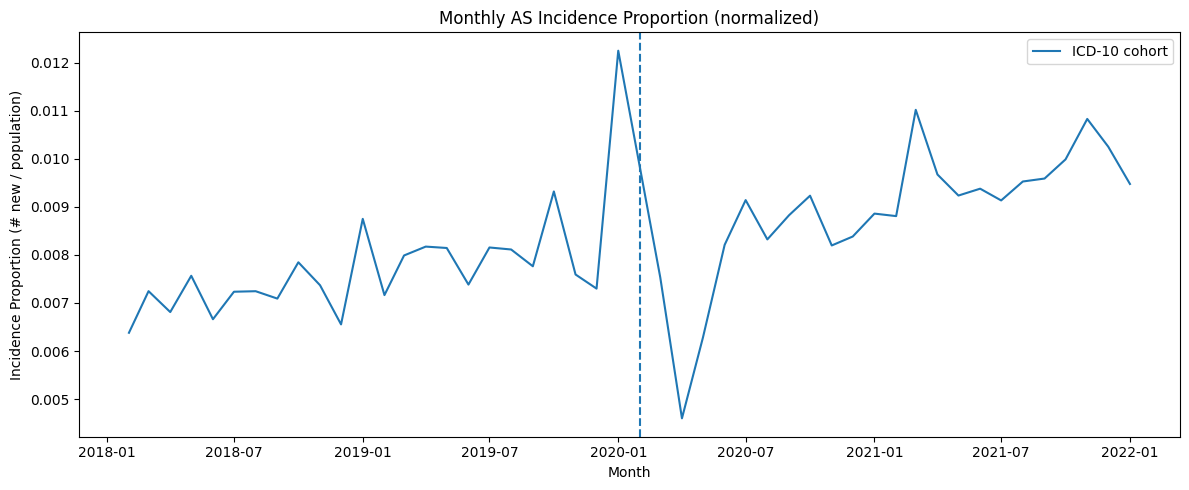

In [17]:
g_icd = prep(g_icd)
g_lab = prep(g_lab)
g_both = prep(g_both)

# Plot incidence proportion
plt.figure(figsize=(12,5))
plt.plot(g_icd["Time Window Start"], g_icd["Incidence Proportion"], label="ICD-10 cohort")

# Mark Feb 2020 boundary
plt.axvline(pd.to_datetime("2020-02-01"), linestyle="--")

plt.title("Monthly AS Incidence Proportion (normalized)")
plt.xlabel("Month")
plt.ylabel("Incidence Proportion (# new / population)")
plt.legend()
plt.tight_layout()
plt.show()


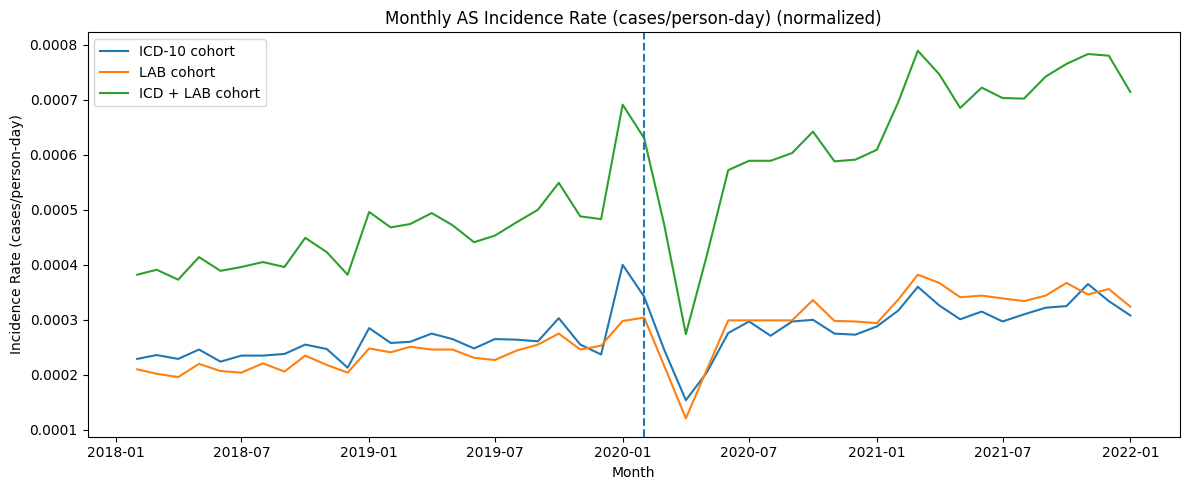

In [18]:
g_icd = prep(g_icd)
g_lab = prep(g_lab)
g_both = prep(g_both)

# Plot incidence proportion
plt.figure(figsize=(12,5))
plt.plot(g_icd["Time Window Start"], g_icd["Incidence Rate (cases/person-day)"], label="ICD-10 cohort")
plt.plot(g_lab["Time Window Start"], g_lab["Incidence Rate (cases/person-day)"], label="LAB cohort")
plt.plot(g_both["Time Window Start"], g_both["Incidence Rate (cases/person-day)"], label="ICD + LAB cohort")

# Mark Feb 2020 boundary
plt.axvline(pd.to_datetime("2020-02-01"), linestyle="--")

plt.title("Monthly AS Incidence Rate (cases/person-day) (normalized)")
plt.xlabel("Month")
plt.ylabel("Incidence Rate (cases/person-day)")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Define pre- and post-COVID windows (month start dates)
pre_start  = pd.to_datetime("2018-02-01")
pre_end    = pd.to_datetime("2020-01-01")   # last pre-COVID month: Jan 2020

post_start = pd.to_datetime("2020-02-01")
post_end   = pd.to_datetime("2022-01-01")   # last post-COVID month: Jan 2022

def summarize_incidence(df, name):
    df = prep(df)  # ensure sorted and datetime

    pre_mask = (df["Time Window Start"] >= pre_start) & (df["Time Window Start"] <= pre_end)
    post_mask = (df["Time Window Start"] >= post_start) & (df["Time Window Start"] <= post_end)

    pre_mean = df.loc[pre_mask, "Incidence Proportion"].mean()
    post_mean = df.loc[post_mask, "Incidence Proportion"].mean()

    pct_change = (post_mean - pre_mean) / pre_mean * 100 if pre_mean != 0 else float("nan")

    return {
        "group": name,
        "pre_mean_incidence": pre_mean,
        "post_mean_incidence": post_mean,
        "percent_change": pct_change,
    }

rows = [
    summarize_incidence(g_icd, "ICD-10 cohort"),
    summarize_incidence(g_lab, "LAB cohort"),
    summarize_incidence(g_both, "ICD + LAB cohort"),
]

summary_df = pd.DataFrame(rows)
summary_df

,group,pre_mean_incidence,post_mean_incidence,percent_change
0,ICD-10 cohort,0.007754,0.008930,15.164165
1,LAB cohort,0.007032,0.009374,33.301144
2,ICD + LAB cohort,0.013663,0.019277,41.090081


In [20]:
pre_start      = pd.to_datetime("2018-02-01")
pre_end_main   = pd.to_datetime("2020-01-01")  # includes Jan 2020
pre_end_sens   = pd.to_datetime("2019-12-01")  # excludes Jan 2020

post_start     = pd.to_datetime("2020-02-01")
post_end       = pd.to_datetime("2022-01-01")

def summarize_incidence_sens(df, name):
    df = prep(df)

    pre_mask_main = (df["Time Window Start"] >= pre_start) & (df["Time Window Start"] <= pre_end_main)
    pre_mask_sens = (df["Time Window Start"] >= pre_start) & (df["Time Window Start"] <= pre_end_sens)
    post_mask     = (df["Time Window Start"] >= post_start) & (df["Time Window Start"] <= post_end)

    pre_mean_main = df.loc[pre_mask_main, "Incidence Proportion"].mean()
    pre_mean_sens = df.loc[pre_mask_sens, "Incidence Proportion"].mean()
    post_mean     = df.loc[post_mask, "Incidence Proportion"].mean()

    pct_change_main = (post_mean - pre_mean_main) / pre_mean_main * 100 if pre_mean_main != 0 else float("nan")
    pct_change_sens = (post_mean - pre_mean_sens) / pre_mean_sens * 100 if pre_mean_sens != 0 else float("nan")

    return {
        "group": name,
        "pre_mean_main": pre_mean_main,
        "pre_mean_sens": pre_mean_sens,
        "post_mean": post_mean,
        "pct_change_main": pct_change_main,   # Main analysis (incl. Jan 2020)
        "pct_change_sens": pct_change_sens,   # Sensitivity (excl. Jan 2020)
    }

rows = [
    summarize_incidence_sens(g_icd, "ICD-10 cohort"),
    summarize_incidence_sens(g_lab, "LAB cohort"),
    summarize_incidence_sens(g_both, "ICD + LAB cohort"),
]

summary_sensitivity = pd.DataFrame(rows)
summary_sensitivity

,group,pre_mean_main,pre_mean_sens,post_mean,pct_change_main,pct_change_sens
0,ICD-10 cohort,0.007754,0.007559,0.008930,15.164165,18.142580
1,LAB cohort,0.007032,0.006940,0.009374,33.301144,35.068275
2,ICD + LAB cohort,0.013663,0.013342,0.019277,41.090081,44.484126


In [25]:
g_icd2 = pd.read_csv("/Users/matiaslee/LOCAL_FILES_SAFE/Dr Facelli Project 2025/AS_DS/ICD 2025.csv")
g_lab2 = pd.read_csv("/Users/matiaslee/LOCAL_FILES_SAFE/Dr Facelli Project 2025/AS_DS/LAB 2025.csv")
g_both2 = pd.read_csv("/Users/matiaslee/LOCAL_FILES_SAFE/Dr Facelli Project 2025/AS_DS/ICD+LAB 2025.csv")



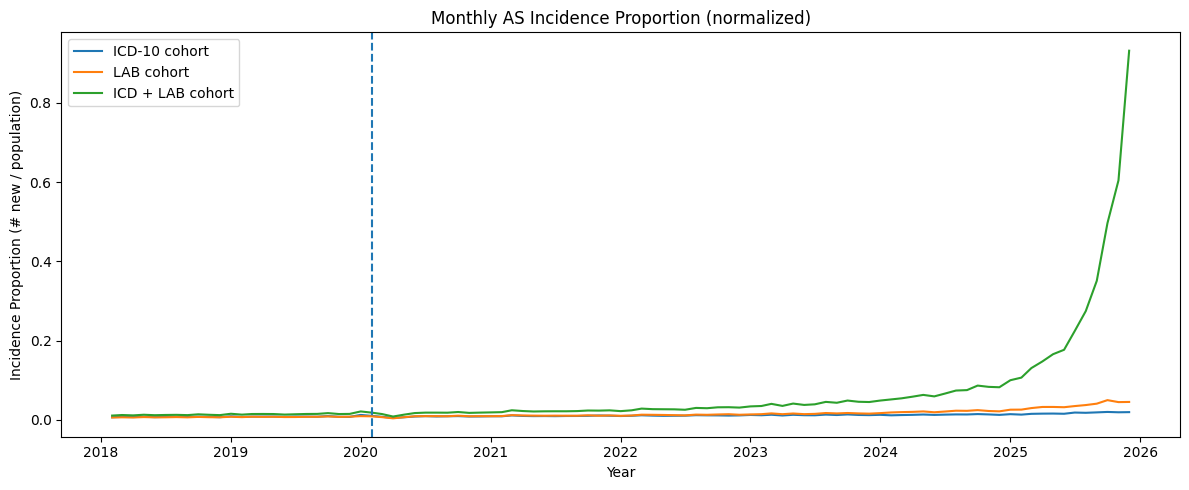

In [27]:
import matplotlib.pyplot as plt

def prep(df):
    df = df.copy()
    df["Time Window Start"] = pd.to_datetime(df["Time Window Start"])
    # Drop exact-duplicate months (or aggregate if needed)
    df = df.drop_duplicates(subset=["Time Window Start"])
    # If you ever expect multiple rows per month, use this instead:
    # df = (
    #     df.groupby("Time Window Start", as_index=False)["Incidence Proportion"]
    #       .mean()
    # )
    df = df.sort_values("Time Window Start")
    return df

g_icd2 = prep(g_icd2)
g_lab2 = prep(g_lab2)
g_both2= prep(g_both2)

# Plot incidence proportion
plt.figure(figsize=(12,5))
plt.plot(g_icd2["Time Window Start"], g_icd2["Incidence Proportion"], label="ICD-10 cohort")
plt.plot(g_lab2["Time Window Start"], g_lab2["Incidence Proportion"], label="LAB cohort")
plt.plot(g_both2["Time Window Start"], g_both2["Incidence Proportion"], label="ICD + LAB cohort")

# Mark Feb 2020 boundary
plt.axvline(pd.to_datetime("2020-02-01"), linestyle="--")

plt.title("Monthly AS Incidence Proportion (normalized)")
plt.xlabel("Year")
plt.ylabel("Incidence Proportion (# new / population)")
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
import pandas as pd

# Define pre/post windows (adjust if needed)
pre_start  = pd.to_datetime("2018-02-01")
pre_end    = pd.to_datetime("2020-01-01")   # last pre-pandemic month

post_start = pd.to_datetime("2020-02-01")
post_end   = pd.to_datetime("2022-01-01")   # last post-pandemic month

def prep2(df):
    df = df.copy()
    df["Time Window Start"] = pd.to_datetime(df["Time Window Start"])
    df = df.drop_duplicates(subset=["Time Window Start"]).sort_values("Time Window Start")
    return df

def summarize_ratio(df, name):
    df = prep2(df)

    pre_mask = (df["Time Window Start"] >= pre_start) & (df["Time Window Start"] <= pre_end)
    post_mask = (df["Time Window Start"] >= post_start) & (df["Time Window Start"] <= post_end)

    pre_mean = df.loc[pre_mask, "Incidence Proportion"].mean()
    post_mean = df.loc[post_mask, "Incidence Proportion"].mean()

    rate_ratio = post_mean / pre_mean if pre_mean != 0 else float("nan")
    pct_change = (rate_ratio - 1) * 100 if pd.notna(rate_ratio) else float("nan")

    return {
        "group": name,
        "pre_mean_incidence": pre_mean,
        "post_mean_incidence": post_mean,
        "rate_ratio_post_vs_pre": rate_ratio,
        "percent_change_post_vs_pre": pct_change,
    }

rows2 = [
    summarize_ratio(g_icd2,  "ICD-10 cohort (updated)"),
    summarize_ratio(g_lab2,  "LAB cohort (updated)"),
    summarize_ratio(g_both2, "ICD + LAB cohort (updated)"),
]

incidence_ratios_2 = pd.DataFrame(rows2)
incidence_ratios_2

,group,pre_mean_incidence,post_mean_incidence,rate_ratio_post_vs_pre,percent_change_post_vs_pre
0,ICD-10 cohort (updated),0.007754,0.008930,1.151642,15.164164
1,LAB cohort (updated),0.007032,0.009374,1.333011,33.301142
2,ICD + LAB cohort (updated),0.013663,0.019277,1.410901,41.090081


In [30]:

rows3 = [
    summarize_ratio(g_icd,  "ICD-10 cohort (updated)"),
    summarize_ratio(g_lab,  "LAB cohort (updated)"),
    summarize_ratio(g_both, "ICD + LAB cohort (updated)"),
]

incidence_ratios_3 = pd.DataFrame(rows3)
incidence_ratios_3

,group,pre_mean_incidence,post_mean_incidence,rate_ratio_post_vs_pre,percent_change_post_vs_pre
0,ICD-10 cohort (updated),0.007754,0.008930,1.151642,15.164165
1,LAB cohort (updated),0.007032,0.009374,1.333011,33.301144
2,ICD + LAB cohort (updated),0.013663,0.019277,1.410901,41.090081



Trend-based pre/post comparison (slopes and endpoint % changes):


,cohort_name,n_pre,n_post,slope_pre,slope_post,slope_ratio,pct_pre,pct_post,pct_ratio
0,ICD-only,24,71,0.000003,0.000004,1.318541,0.920268,0.964714,1.048296
1,LAB-only (HLA+),24,71,0.000003,0.000014,4.353843,0.565502,4.154347,7.346307
2,ICD+LAB,24,71,0.000008,0.000136,16.836600,0.982655,50.674925,51.569392



Saved CSV to 'as_incidence_pre_post_ratios.csv'


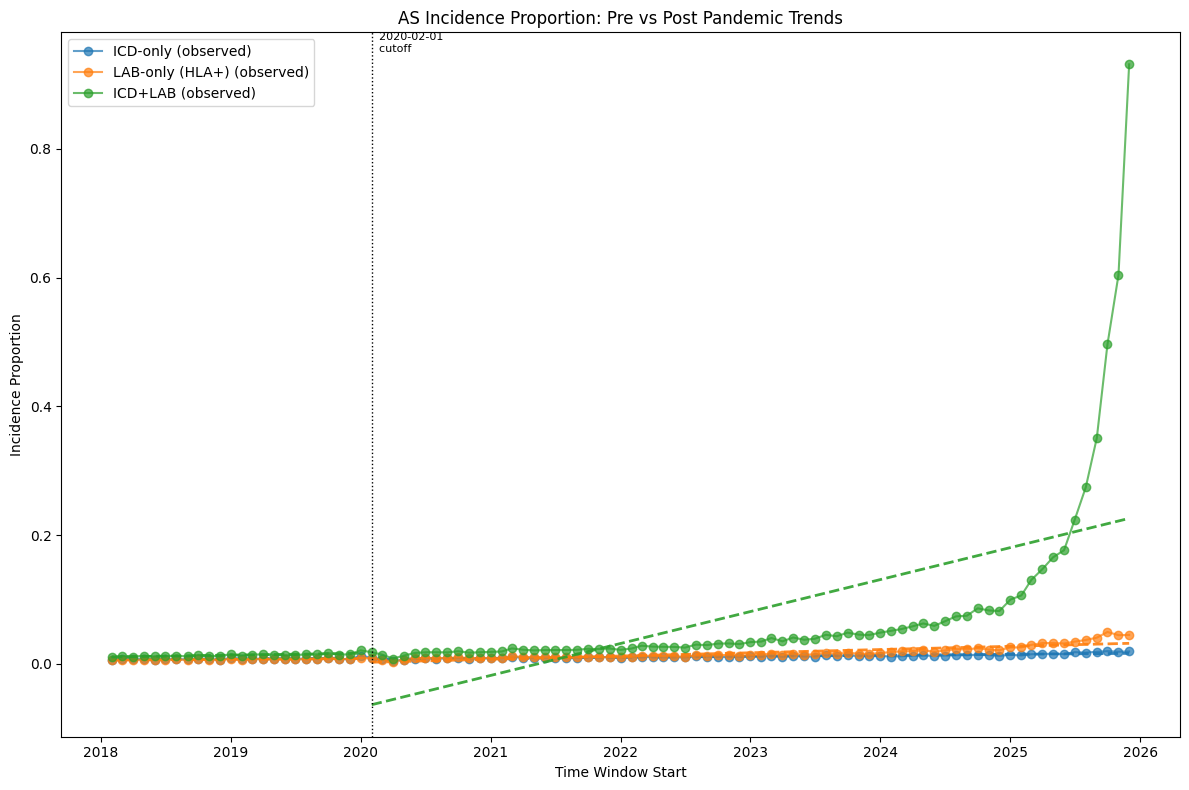

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --- CONFIG ---
CUTOFF = pd.Timestamp("2020-02-01")  # pandemic cutoff

cohorts = [
    ("ICD-only", g_icd2),
    ("LAB-only (HLA+)", g_lab2),
    ("ICD+LAB", g_both2),
]

# --- HELPERS ---

def prep_for_trend(df):
    """Ensure clean, sorted, de-duplicated time series."""
    df = df.copy()
    df["Time Window Start"] = pd.to_datetime(df["Time Window Start"])
    df = df.dropna(subset=["Time Window Start", "Incidence Proportion"])
    # Drop exact duplicate months (or aggregate if needed)
    df = df.drop_duplicates(subset=["Time Window Start"])
    df = df.sort_values("Time Window Start")
    return df

def period_metrics(sub, period_label):
    """
    Given a cleaned subset with columns:
      - Time Window Start (datetime)
      - Incidence Proportion (float)
    compute:
      - n points
      - slope (from linregress) or NaN if n<2
      - percent change (last-first)/first or NaN if first==0 or n<2
    """
    n = len(sub)
    if n < 2:
        return {
            f"n_{period_label}": n,
            f"slope_{period_label}": np.nan,
            f"pct_{period_label}": np.nan,
        }

    # Convert time to numeric: days since first point in this period
    t0 = sub["Time Window Start"].iloc[0]
    x = (sub["Time Window Start"] - t0).dt.days.astype(float)
    y = sub["Incidence Proportion"].astype(float)

    res = linregress(x, y)
    slope = res.slope

    first_y = y.iloc[0]
    last_y = y.iloc[-1]
    if first_y == 0 or np.isnan(first_y):
        pct_change = np.nan
    else:
        pct_change = (last_y - first_y) / first_y

    return {
        f"n_{period_label}": n,
        f"slope_{period_label}": slope,
        f"pct_{period_label}": pct_change,
    }

def analyze_cohort(df, name):
    df = prep_for_trend(df)

    pre = df[df["Time Window Start"] < CUTOFF]
    post = df[df["Time Window Start"] >= CUTOFF]

    m_pre = period_metrics(pre, "pre")
    m_post = period_metrics(post, "post")

    slope_pre = m_pre["slope_pre"]
    slope_post = m_post["slope_post"]
    pct_pre = m_pre["pct_pre"]
    pct_post = m_post["pct_post"]

    # Safe ratios
    if slope_pre == 0 or np.isnan(slope_pre):
        slope_ratio = np.nan
    else:
        slope_ratio = slope_post / slope_pre

    if pct_pre == 0 or np.isnan(pct_pre):
        pct_ratio = np.nan
    else:
        pct_ratio = pct_post / pct_pre

    row = {
        "cohort_name": name,
        **m_pre,
        **m_post,
        "slope_ratio": slope_ratio,
        "pct_ratio": pct_ratio,
    }
    return row, df, pre, post

# --- RUN ANALYSIS AND BUILD SUMMARY TABLE ---

rows = []
plot_data = []  # keep cleaned df + pre/post subsets for plotting

for name, df in cohorts:
    row, df_clean, pre_sub, post_sub = analyze_cohort(df, name)
    rows.append(row)
    plot_data.append((name, df_clean, pre_sub, post_sub))

summary_trend = pd.DataFrame(rows, columns=[
    "cohort_name",
    "n_pre", "n_post",
    "slope_pre", "slope_post", "slope_ratio",
    "pct_pre", "pct_post", "pct_ratio",
])

print("\nTrend-based pre/post comparison (slopes and endpoint % changes):")
display(summary_trend)

summary_trend.to_csv("as_incidence_pre_post_ratios.csv", index=False)
print("\nSaved CSV to 'as_incidence_pre_post_ratios.csv'")

# --- PLOT TIME SERIES + FITTED PRE/POST LINES ---

plt.figure(figsize=(12, 8))

colors = {
    "ICD-only": "tab:blue",
    "LAB-only (HLA+)": "tab:orange",
    "ICD+LAB": "tab:green",
}

for name, df_clean, pre_sub, post_sub in plot_data:
    c = colors.get(name, None)

    # Plot full time series
    plt.plot(
        df_clean["Time Window Start"],
        df_clean["Incidence Proportion"],
        marker="o", linestyle="-", label=f"{name} (observed)",
        alpha=0.7, color=c,
    )

    # Helper to fit and draw a segment for a period
    def draw_segment(sub, label_suffix):
        if len(sub) < 2:
            return
        t0 = sub["Time Window Start"].iloc[0]
        x = (sub["Time Window Start"] - t0).dt.days.astype(float)
        y = sub["Incidence Proportion"].astype(float)
        res = linregress(x, y)
        y_fit = res.intercept + res.slope * x
        plt.plot(
            sub["Time Window Start"],
            y_fit,
            linestyle="--",
            linewidth=2,
            color=c,
            alpha=0.9,
        )

    # Draw pre and post trend lines
    draw_segment(pre_sub, "pre")
    draw_segment(post_sub, "post")

# Vertical cutoff line
plt.axvline(CUTOFF, color="k", linestyle=":", linewidth=1)
plt.text(
    CUTOFF, plt.ylim()[1],
    "  2020-02-01\n  cutoff",
    va="top", ha="left", fontsize=8,
)

plt.title("AS Incidence Proportion: Pre vs Post Pandemic Trends")
plt.xlabel("Time Window Start")
plt.ylabel("Incidence Proportion")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
import numpy as np
import pandas as pd

PRE_START  = pd.Timestamp("2018-02-01")
PRE_END    = pd.Timestamp("2020-01-01")
POST_START = pd.Timestamp("2020-02-01")
POST_END   = pd.Timestamp("2025-01-01")   # change to your last available month if needed

def ratio_of_increase(df, name):
    df = df.copy()
    df["Time Window Start"] = pd.to_datetime(df["Time Window Start"], errors="coerce")
    df = df.dropna(subset=["Time Window Start", "Incidence Proportion"])
    df = df.sort_values("Time Window Start")

    pre  = df[(df["Time Window Start"] >= PRE_START) & (df["Time Window Start"] <= PRE_END)]
    post = df[(df["Time Window Start"] >= POST_START) & (df["Time Window Start"] <= POST_END)]

    # Need at least 2 points per period
    if len(pre) < 2 or len(post) < 2:
        return {"group": name, "pre_increase": np.nan, "post_increase": np.nan, "ratio_post_vs_pre": np.nan}

    pre_increase  = pre["Incidence Proportion"].iloc[-1]  - pre["Incidence Proportion"].iloc[0]
    post_increase = post["Incidence Proportion"].iloc[-1] - post["Incidence Proportion"].iloc[0]

    ratio = np.nan if np.isclose(pre_increase, 0) else (post_increase / pre_increase)

    return {
        "group": name,
        "pre_increase": pre_increase,
        "post_increase": post_increase,
        "ratio_post_vs_pre": ratio,
    }

rows = [
    ratio_of_increase(g_icd2,  "ICD-only"),
    ratio_of_increase(g_lab2,  "LAB-only (HLA+)"),
    ratio_of_increase(g_both2, "ICD+LAB"),
]

ratios = pd.DataFrame(rows)
ratios


,group,pre_increase,post_increase,ratio_post_vs_pre
0,ICD-only,0.005871,0.004353,0.741461
1,LAB-only (HLA+),0.003305,0.016724,5.060751
2,ICD+LAB,0.010430,0.081790,7.841543


In [34]:
rows2 = [
    ratio_of_increase(g_icd,  "ICD-only"),
    ratio_of_increase(g_lab,  "LAB-only (HLA+)"),
    ratio_of_increase(g_both, "ICD+LAB"),
]

ratios2 = pd.DataFrame(rows2)
ratios2


,group,pre_increase,post_increase,ratio_post_vs_pre
0,ICD-only,0.005871,-0.000341,-0.058033
1,LAB-only (HLA+),0.003305,0.001229,0.371846
2,ICD+LAB,0.010430,0.003799,0.364265
